# Evaluación del modelo clasificador de riesgo IA

En este notebook evaluamos el modelo entrenado sobre el conjunto de test.

Métricas:
1. Classification report (precision, recall, f1 por clase)
2. F1-score macro
3. Matriz de confusión
4. Curva ROC multiclase (One-vs-Rest)
5. Análisis de errores
6. Registro de métricas en MLflow

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_dataset_real"))
        break

import functions
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_ia_real"

## 1. Carga del modelo y datos de test

In [3]:
import os
import pandas as pd
import joblib
from scipy.sparse import csr_matrix, hstack

# Cargar modelo y artefactos del pipeline
modelo = joblib.load("model/modelo_baseline.joblib")
tfidf  = joblib.load("model/tfidf_vectorizer.joblib")
ohe    = joblib.load("model/ohe_encoder.joblib") if os.path.exists("model/ohe_encoder.joblib") else None

print("Artefactos cargados correctamente.")

test_df = pd.read_csv("data/processed/test.csv")
X_test_text = test_df["text_final"]
y_test      = test_df["etiqueta"]

# Construir la misma matriz de features que usó el entrenamiento
X_test_tfidf = tfidf.transform(X_test_text)

if ohe is not None:
    CAT_COLS = ["category", "context"]
    NUM_COLS = ["longitud", "num_articles"]
    cat_test = ohe.transform(test_df[CAT_COLS])
    num_test = csr_matrix(test_df[NUM_COLS].values.astype(float))
    X_test_final = hstack([X_test_tfidf, cat_test, num_test])
    print(f"Pipeline: TF-IDF ({X_test_tfidf.shape[1]}) + OHE ({cat_test.shape[1]}) + numéricas ({len(NUM_COLS)}) = {X_test_final.shape[1]} features")
else:
    X_test_final = X_test_tfidf
    print(f"Pipeline: solo TF-IDF ({X_test_final.shape[1]} features) — ohe_encoder.joblib no encontrado")

print(f"\nTest: {len(X_test_text)} muestras")
print(f"Clases: {sorted(y_test.unique())}")

Artefactos cargados correctamente.
Pipeline: TF-IDF (3773) + OHE (22) + numéricas (2) = 3797 features

Test: 45 muestras
Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']


## 2. Classification report y F1-score macro

In [4]:
from functions import evaluar_modelo

y_pred, report_dict = evaluar_modelo(modelo, X_test_final, y_test)

=== Resultados en TEST ===

                 precision    recall  f1-score   support

    alto_riesgo       0.29      0.29      0.29         7
    inaceptable       0.57      0.40      0.47        20
riesgo_limitado       0.33      0.67      0.44         3
  riesgo_minimo       0.56      0.67      0.61        15

       accuracy                           0.49        45
      macro avg       0.44      0.50      0.45        45
   weighted avg       0.51      0.49      0.49        45

F1-score macro (test): 0.4517



## 3. Matriz de confusión

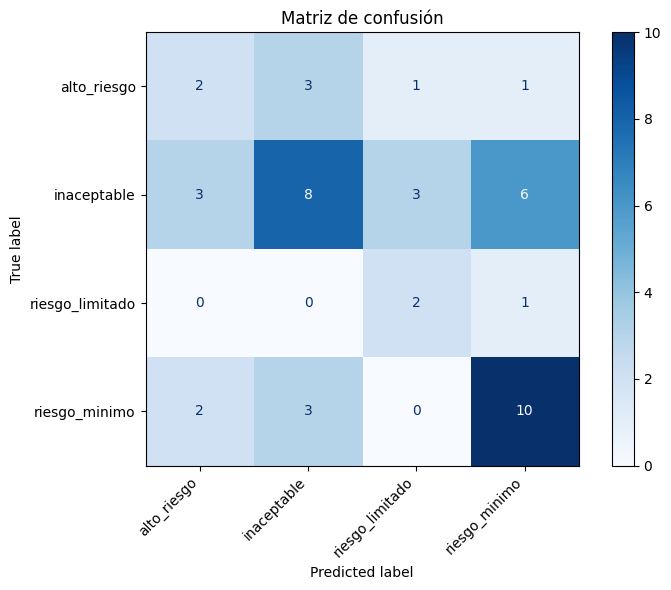

In [5]:
from functions import mostrar_matriz_confusion

clases = sorted(y_test.unique())
fig_cm = mostrar_matriz_confusion(y_test, y_pred, labels=clases)

## 4. Curva ROC multiclase

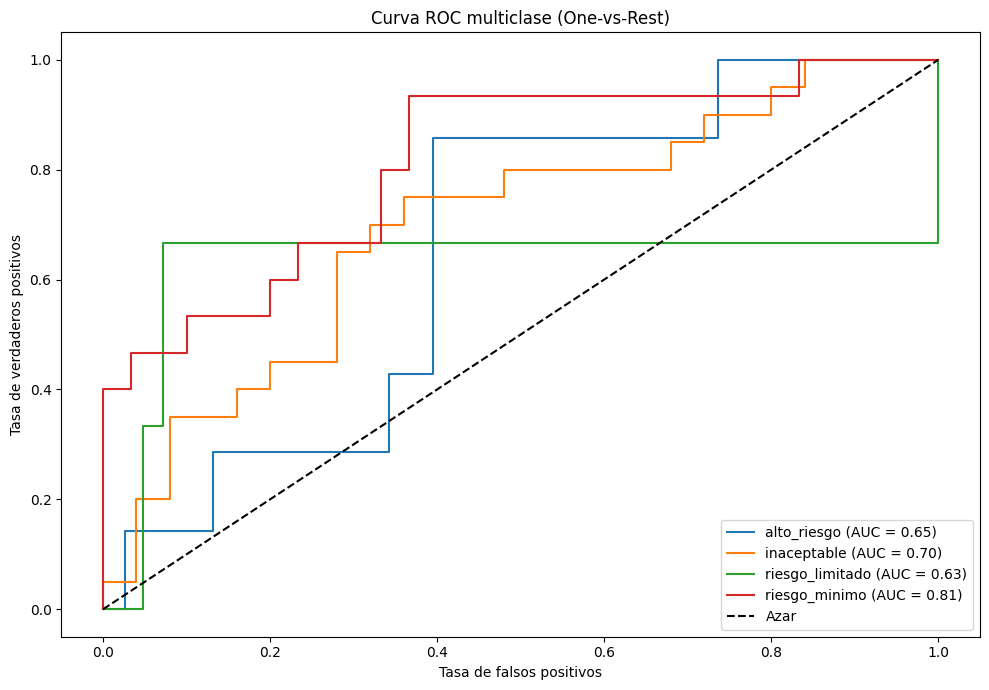


ROC AUC macro: 0.6981
  alto_riesgo: 0.6541
  inaceptable: 0.6980
  riesgo_limitado: 0.6270
  riesgo_minimo: 0.8133


In [6]:
from functions import plot_curva_roc_multiclase

fig_roc, roc_auc_dict = plot_curva_roc_multiclase(modelo, X_test_final, y_test)

## 5. Análisis de errores

In [7]:
from functions import analisis_errores

df_errores = analisis_errores(modelo, X_test_final, y_test, X_test_text=X_test_text)

Total de errores: 23 de 45 (51.1%)

Confusiones más frecuentes:
etiqueta_real    etiqueta_predicha
inaceptable      riesgo_minimo        6
alto_riesgo      inaceptable          3
inaceptable      riesgo_limitado      3
riesgo_minimo    inaceptable          3
inaceptable      alto_riesgo          3
riesgo_minimo    alto_riesgo          2
alto_riesgo      riesgo_minimo        1
                 riesgo_limitado      1
riesgo_limitado  riesgo_minimo        1
dtype: int64

Ejemplos mal clasificados:
  Real: inaceptable | Predicho: alto_riesgo
  Texto: plataforma comercio electrónico utilizar sistema recomendación impulsado inteligencia artificial manipular usuario reali...

  Real: alto_riesgo | Predicho: inaceptable
  Texto: empresa servicio legal utilizar sistema inteligencia artificial automatizar revisión contrato sistema basar dato persona...

  Real: riesgo_minimo | Predicho: alto_riesgo
  Texto: sistema inteligencia artificial utilizado compañía seguro analizar dato histórico reclama

## 6. Registro de métricas en MLflow

In [8]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
import numpy as np
import mlflow
from functions import configure_mlflow, MLFLOW_EXPERIMENT

# Guardar gráficos localmente (no depende del servidor)
fig_cm.savefig("model/matriz_confusion.png", dpi=150, bbox_inches="tight")
fig_roc.savefig("model/curva_roc.png", dpi=150, bbox_inches="tight")

try:
    configure_mlflow()
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name="evaluacion_test"):
        mlflow.log_metric("test_f1_macro",        report_dict["macro avg"]["f1-score"])
        mlflow.log_metric("test_accuracy",         report_dict["accuracy"])
        mlflow.log_metric("test_precision_macro",  report_dict["macro avg"]["precision"])
        mlflow.log_metric("test_recall_macro",     report_dict["macro avg"]["recall"])

        for clase, auc_val in roc_auc_dict.items():
            mlflow.log_metric(f"test_roc_auc_{clase}", auc_val)
        mlflow.log_metric("test_roc_auc_macro", np.mean(list(roc_auc_dict.values())))

        mlflow.log_artifact("model/matriz_confusion.png")
        mlflow.log_artifact("model/curva_roc.png")

        print("✓ Métricas de test registradas en MLflow")
        print(f"  F1-score macro: {report_dict['macro avg']['f1-score']:.4f}")
        print(f"  Run ID: {mlflow.active_run().info.run_id}")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

⚠ MLflow no disponible: MLFLOW_TRACKING_URI no está configurada.
Añádela al archivo .env: MLFLOW_TRACKING_URI=https://...


Instala las dependencias desde `requirements.txt` antes de ejecutar este notebook:
```bash
pip install -r requirements.txt
```

## 7. Conclusiones

Documentar aquí las conclusiones tras observar las métricas:
- ¿Qué clases se confunden más entre sí?
- ¿El modelo generaliza bien o muestra signos de overfitting?
- ¿Qué mejoras se podrían probar en iteraciones futuras?